<div align="left" style="background-color: #008080; padding: 20px 10px;">
<h3><b>IDEAS - Institute of Data Engineering, Analytics and Science Foundation</b></h3>
<p>Summer Internship Program 2026</p>
<hr style="width:100%;">
<h3><b>Project Title:</b> Used Car Price Prediction Using Regression Models</h3>
<h4>Project Notebook</h4>

<blockquote style="border-left: 4px solid #4285F4; padding-left: 15px;">
  <strong>Created by:</strong> Suprava Das<br>
  <strong>Designation:</strong> Associate Software Developer
</blockquote>
<hr style="width:100%;">
</div>

### Question 1: Import Packages and Load the Dataset (1 Mark)

Import `pandas` as `pd`. Download the dataset `used_cars.csv` from https://drive.google.com/drive/folders/1gieHICVDBbUKMZiSF4YRQMAJic-w50JM?usp=sharing. Load the dataset `used_cars.csv` into a DataFrame named `df`. 
Create a copy of the DataFrame named `df1` to preserve the original data for future reference.

**Expected Output:** The code cell should execute without any errors.

In [205]:
import pandas as pd

df = pd.read_csv('used_cars.csv')
df1 = df.copy()

### Question 2: Shuffle and Display the Dataset (1 Mark)

Shuffle the dataset `df1` using `.sample(frac=1, random_state=42)` to ensure the data is randomly distributed. Display the top 10 rows of the shuffled dataset.

**Expected Output:** A table showing the first 10 rows of the randomized DataFrame.

In [206]:
df1 = df1.sample(frac=1, random_state=42)
df1.head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
2580,Lexus,IS 300 Base,2018,"50,992 mi.",Gasoline,260.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,White,Gray,At least 1 accident or damage reported,Yes,"$28,000"
3660,Chevrolet,Impala Base,2004,"64,500 mi.",Gasoline,180.0HP 3.4L V6 Cylinder Engine Gasoline Fuel,A/T,Beige,Beige,None reported,Yes,"$5,900"
897,RAM,2500 SLT,2017,"86,000 mi.",Diesel,350.0HP 6.7L Straight 6 Cylinder Engine Diesel...,6-Speed A/T,Gray,Gray,At least 1 accident or damage reported,Yes,"$41,000"
2091,Mercedes-Benz,SL-Class SL 550,2013,"24,933 mi.",Gasoline,429.0HP 4.6L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Silver,Red,At least 1 accident or damage reported,Yes,"$40,250"
1044,Ford,Shelby GT350R Base,2018,"18,500 mi.",Gasoline,526.0HP 5.2L 8 Cylinder Engine Gasoline Fuel,M/T,Blue,Black,At least 1 accident or damage reported,Yes,"$77,999"
2320,GMC,Yukon SLT,2018,"85,500 mi.",Gasoline,355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,Yes,"$35,899"
465,Volvo,V60 Cross Country T5,2020,"10,500 mi.",Gasoline,250.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,8-Speed A/T,White,Black,None reported,Yes,"$36,000"
196,Nissan,Titan XD SV,2020,"10,001 mi.",Gasoline,5.6L V8 32V GDI DOHC,9-Speed Automatic,Black,Black,None reported,Yes,"$47,214"
3113,BMW,330 i,2005,"59,300 mi.",Gasoline,225.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,M/T,Red,Black,None reported,Yes,"$30,900"
3553,Lexus,RX 330 Base,2006,"110,250 mi.",Gasoline,230.0HP 3.3L V6 Cylinder Engine Gasoline Fuel,A/T,White,Beige,None reported,Yes,"$11,000"


### Question 3: Dataset Overview and Missing Values (2 Marks)

Print the total number of data points (rows) in the dataset `df1`. Then, find and print the number of null (missing) values present in each column.

**Expected Output:** The total row count and a Series showing the count of nulls per column.

In [207]:
print("Total rows:", len(df1))
print(df1.isnull().sum())

Total rows: 4009
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


### Question 4: Standardize Missing or Invalid Strings (2 Marks)

For all columns with an `object` (string) data type in `df1`, perform the following replacements to standardize missing data:
- Replace the specific character `'–'` with the string `'Unknown'`.
- Replace the string `'nan'` with `'Unknown'`.
- Replace any entirely empty strings or strings consisting only of whitespace with `'Unknown'`.

**Expected Output:** The code cell should execute without errors, standardizing the text data.

In [208]:
obj_cols = df1.select_dtypes(include='object').columns

for col in obj_cols:
    df1[col] = df1[col].astype(str)
    df1[col] = df1[col].replace('–', 'Unknown')
    df1[col] = df1[col].replace('nan', 'Unknown')
    df1[col] = df1[col].replace(r'^\s*$', 'Unknown', regex=True)

#print(df1.isnull().sum())

### Question 5: Feature Engineering - Car Age (1 Mark)

Create a new column named `car_age` in `df1` by calculating the age of each car. You can do this by subtracting the `model_year` from the current year (use `2026` as the current year). 
After calculating the age, drop the original `model_year` column from the DataFrame.

**Expected Output:** The code cell should execute without errors.

In [209]:
df1['car_age'] = 2026 - df1['model_year']
df1.drop(columns=['model_year'], inplace=True)

#print(df1.head())

### Question 6: Format Numeric Columns (1 Mark)

Clean the following two columns so they can be used as numbers:
1. **milage:** Remove the string `' mi.'` and any commas (`,`), then convert the column to integers.
2. **price:** Remove currency symbols (`$`) and any commas (`,`), then convert the column to floats.

**Expected Output:** The code cell should execute without errors, changing both columns to numeric types.

In [210]:
df1['milage'] = (
    df1['milage']
    .astype(str)
    .str.replace(' mi.', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(int)
)

df1['price'] = (
    df1['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

#print(df1.head())

### Question 7: Handle Low-Frequency Categories (2 Marks)

Some categorical columns have too many rare values. For both the `transmission` and `ext_col` columns, group categories that appear in **less than 1%** of the total dataset into a new category called `'others'`.
Additionally, drop the `clean_title` column entirely as it provides little variance.

**Expected Output:** The code cell should execute without errors.

In [211]:
for col in ['transmission', 'ext_col']:
    freq = df1[col].value_counts(normalize=True)
    rare = freq[freq < 0.01].index
    df1[col] = df1[col].replace(rare, 'others')

df1.drop(columns=['clean_title'], inplace=True)

### Question 8: Remove Outliers and Apply Label Encoding (2 Marks)

Remove price outliers by filtering `df1` to keep only rows where the `price` is **below the 99th percentile**.
Next, import `LabelEncoder` from `sklearn.preprocessing` and apply it to convert all remaining categorical (`object`) columns into numerical values.

**Expected Output:** The code cell should execute without errors.

In [212]:
from sklearn.preprocessing import LabelEncoder

p99 = df1['price'].quantile(0.99)
df1 = df1[df1['price'] < p99]

le = LabelEncoder()
for col in df1.select_dtypes(include='object').columns:
    df1[col] = le.fit_transform(df1[col].astype(str))

### Question 9: Train-Test Split (1 Mark)

Define the `price` column as your target variable (`y`) and separate the remaining columns to form the feature set (`X`). 
Split the features and target into training and testing datasets using an 80:20 ratio (`test_size=0.2`) and set `random_state=42`. Print the shapes of the resulting `X_train` and `X_test`.

**Expected Output:** A printout of the dimensions (shape) for the training and testing feature sets.

In [213]:
from sklearn.model_selection import train_test_split

X = df1.drop('price', axis=1)
y = df1['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (3174, 10)
X_test shape: (794, 10)


### Question 10: Model Training and Evaluation (4 Marks)

Import `RandomForestRegressor` from `sklearn.ensemble`, and `r2_score`, `mean_squared_error`, `mean_absolute_error` from `sklearn.metrics`. 
Train the Random Forest model (with `n_estimators=100`, `random_state=42`) on the training data. Predict the prices for the test data and evaluate the model by printing the R² Score, MSE, and MAE.

**Expected Output:** Three numeric values representing the R² score, Mean Squared Error, and Mean Absolute Error of the model.

In [214]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.7422473984607999
MSE: 357090522.2199794
MAE: 9981.921410579345


### Question 11: Load MNIST Data (3 Marks)

Load the MNIST dataset using `sklearn.datasets.load_digits`. Separate the dataset into features (`X`) and target labels (`y`).
Print the shape of the features and the target arrays.

**Expected Output:** The shape of `X` and `y`.

In [215]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1797, 64)
y shape: (1797,)


### Question 12: K-Means Clustering (5 Marks)

Import `KMeans` from `sklearn.cluster`. Initialize and fit the K-Means clustering model on the MNIST features (`X`). 
Since we know there are 10 digits (0-9), set the number of clusters to 10. Assign the cluster labels to a variable `kmeans_labels`.

**Expected Output:** A successfully fitted K-Means model and the cluster labels array.

In [216]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
kmeans.fit(X)

kmeans_labels = kmeans.labels_
kmeans_labels

array([1, 3, 3, ..., 3, 8, 8], shape=(1797,), dtype=int32)

### Question 13: F1 Score Evaluation for Clustering (5 Marks)

Evaluate the clustering performance using the F1 score. Since K-Means assigns arbitrary cluster labels, you will first need to map each cluster label to the most frequent true label in that cluster. 
After mapping the labels, calculate and print the macro-averaged F1 score using `sklearn.metrics.f1_score`.

**Expected Output:** The calculated F1 score of the clustering.

In [217]:
from sklearn.metrics import f1_score
from scipy.stats import mode
import numpy as np

mapped_labels = np.zeros_like(kmeans_labels)

for cluster in np.unique(kmeans_labels):
    mask = kmeans_labels == cluster
    mapped_labels[mask] = mode(y[mask], keepdims=False).mode

f1 = f1_score(y, mapped_labels, average='macro')
print("Macro F1 Score:", f1)

Macro F1 Score: 0.7894620863890832


# Additional Visualizations for Internship Report

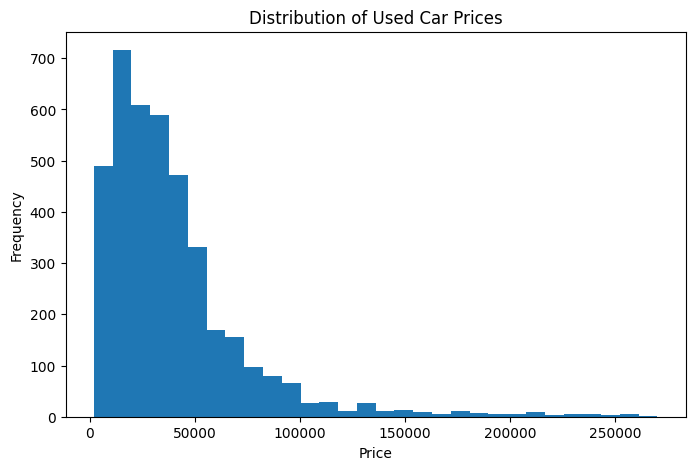

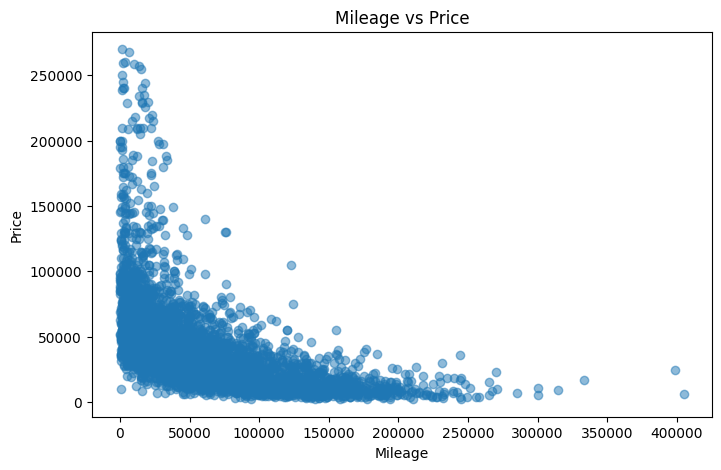

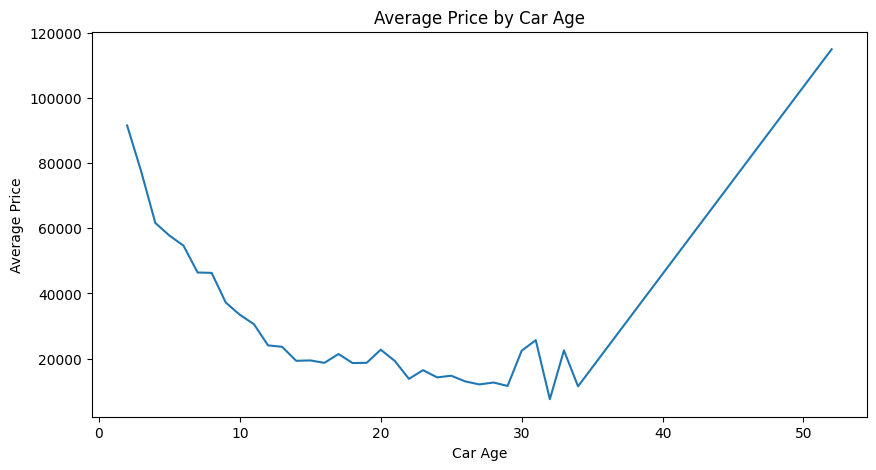

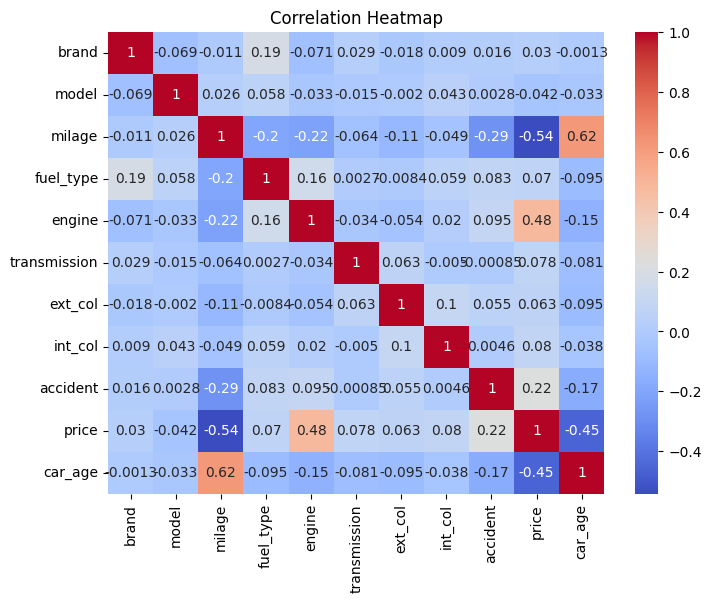

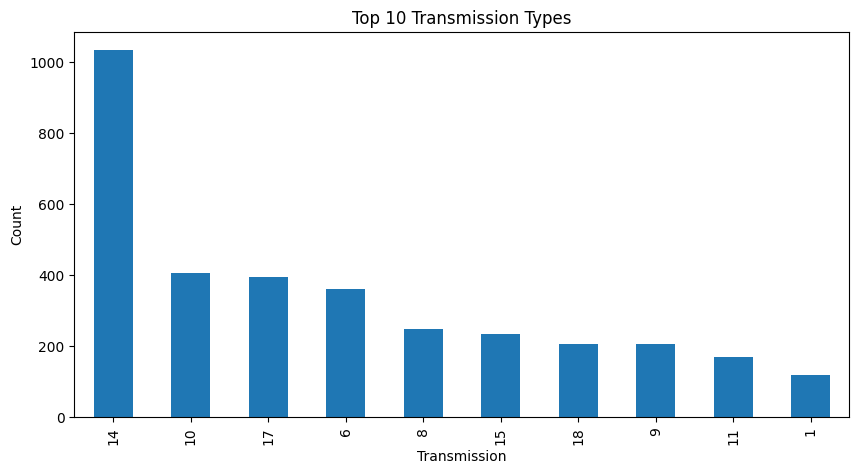

In [218]:
import matplotlib.pyplot as plt

# Distribution of car prices
plt.figure(figsize=(8,5))
plt.hist(df1['price'], bins=30)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Scatter plot of mileage vs price
plt.figure(figsize=(8,5))
plt.scatter(df1['milage'], df1['price'], alpha=0.5)
plt.title('Mileage vs Price')
plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

# Average price by car age
avg_price = df1.groupby('car_age')['price'].mean()
plt.figure(figsize=(10,5))
avg_price.plot(kind='line')
plt.title('Average Price by Car Age')
plt.xlabel('Car Age')
plt.ylabel('Average Price')
plt.show()

# Correlation heatmap
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(
    df1.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

# Bar plot of transmission types
plt.figure(figsize=(10,5))
df1['transmission'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Transmission Types')
plt.xlabel('Transmission')
plt.ylabel('Count')
plt.show()